# СИСТЕМА ОБНАРУЖЕНИЯ СТЕГАНОГРАФИИ С ПОМОЩЬЮ SRNet (Steganalysis ResNet)

In [1]:
# Монтирование Google Drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Проверка версии PyTorch

import torch
print(f"PyTorch version: {torch.__version__}")


PyTorch version: 2.10.0+cu128


In [3]:
# Импорт библиотек

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import os
from typing import List

In [5]:
# 1. Загрузка и анализ датасета

dataset_path = "/content/drive/MyDrive/FQW/Cats-vs-Dogs-Gray-1000"
dataset_root = Path(dataset_path)

print(f"Сканирование: {dataset_root}")

data = []

# Обработка папки с кошками
cat_folder = dataset_root / "cat"
if cat_folder.exists():
    for img_path in sorted(cat_folder.glob("*.*")):
        if img_path.suffix.lower() in {".jpg", ".jpeg", ".png"}:
            data.append({
                "path": str(img_path),
                "label": "cat",
                "label_num": 0,
                "filename": img_path.name,
                "ext": img_path.suffix.lower(),
            })
    print(f" Кошек найдено: {len([d for d in data if d['label'] == 'cat'])}")
else:
    print(f" Папка не найдена: {cat_folder}")

# Обработка папки с собаками
dog_folder = dataset_root / "dog"
if dog_folder.exists():
    for img_path in sorted(dog_folder.glob("*.*")):
        if img_path.suffix.lower() in {".jpg", ".jpeg", ".png"}:
            data.append({
                "path": str(img_path),
                "label": "dog",
                "label_num": 1,
                "filename": img_path.name,
                "ext": img_path.suffix.lower(),
            })
    print(f" Собак найдено: {len([d for d in data if d['label'] == 'dog'])}")
else:
    print(f" Папка не найдена: {dog_folder}")

df = pd.DataFrame(data)
print(f"\nВсего изображений: {len(df)}")
print(f"\n=== Статистика датасета ===")
print(f"Распределение классов:")
print(df["label"].value_counts())
print(f"\nБаланс классов:")
print((df["label"].value_counts() / len(df) * 100).round(2))

# Сохранение индекса
index_file = dataset_root / "dataset_index.csv"
df.to_csv(index_file, index=False)
print(f"\n Индекс сохранен: {index_file}")

Сканирование: /content/drive/MyDrive/FQW/Cats-vs-Dogs-Gray-1000
 Кошек найдено: 999
 Собак найдено: 1000

Всего изображений: 1999

=== Статистика датасета ===
Распределение классов:
label
dog    1000
cat     999
Name: count, dtype: int64

Баланс классов:
label
dog    50.03
cat    49.97
Name: count, dtype: float64

 Индекс сохранен: /content/drive/MyDrive/FQW/Cats-vs-Dogs-Gray-1000/dataset_index.csv


In [6]:
# 2. АРХИТЕКТУРА SRNet (Steganalysis ResNet)

class HPF_Layer(nn.Module):
    def __init__(self):
        super().__init__()
        self.hpf_filters = nn.Conv2d(1, 5, kernel_size=5, stride=1, padding=2, bias=False)

        srm_weights = np.zeros((5, 1, 5, 5), dtype=np.float32)

        srm_weights[0, 0] = [
            [0, 0, 0, 0, 0],
            [0, -1, 2, -1, 0],
            [0, 2, -4, 2, 0],
            [0, -1, 2, -1, 0],
            [0, 0, 0, 0, 0]
        ]

        srm_weights[1, 0] = [
            [0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0],
            [0, 1, -2, 1, 0],
            [0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0]
        ]

        srm_weights[2, 0] = [
            [0, 0, 0, 0, 0],
            [0, 0, 1, 0, 0],
            [0, 0, -2, 0, 0],
            [0, 0, 1, 0, 0],
            [0, 0, 0, 0, 0]
        ]

        srm_weights[3, 0] = [
            [0, 0, 0, 0, 0],
            [0, 1, 0, 0, 0],
            [0, 0, -2, 0, 0],
            [0, 0, 0, 1, 0],
            [0, 0, 0, 0, 0]
        ]

        srm_weights[4, 0] = [
            [0, 0, 0, 0, 0],
            [0, 0, 0, 1, 0],
            [0, 0, -2, 0, 0],
            [0, 1, 0, 0, 0],
            [0, 0, 0, 0, 0]
        ]

        self.hpf_filters.weight.data = torch.from_numpy(srm_weights)
        self.hpf_filters.weight.requires_grad = False

    def forward(self, x):
        return self.hpf_filters(x)


class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        if in_channels != out_channels or stride != 1:
            self.skip = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )
        else:
            self.skip = nn.Identity()

    def forward(self, x):

        out = torch.abs(x)
        out = torch.tanh(out)

        residual = self.skip(x)

        out = self.conv1(out)
        out = self.bn1(out)
        out = F.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out += residual
        out = F.relu(out)

        return out


class SRNet(nn.Module):
    def __init__(self, num_classes=2, input_size=256):
        super().__init__()

        self.hpf = HPF_Layer()

        self.conv1 = nn.Sequential(
            nn.Conv2d(5, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )

        self.layer1 = self._make_layer(64, 64, 3, stride=2)
        self.layer2 = self._make_layer(64, 128, 3, stride=2)
        self.layer3 = self._make_layer(128, 256, 3, stride=2)
        self.layer4 = self._make_layer(256, 512, 3, stride=2)

        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

        self._initialize_weights()

    def _make_layer(self, in_channels, out_channels, num_blocks, stride):
        layers = []
        layers.append(ResidualBlock(in_channels, out_channels, stride))
        for _ in range(1, num_blocks):
            layers.append(ResidualBlock(out_channels, out_channels, 1))
        return nn.Sequential(*layers)

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.hpf(x)
        x = self.conv1(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.global_pool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


# Тест
model = SRNet(input_size=256)
print(f"\n   Модель SRNet создана")
print(f"   Обучаемых параметров: {model.count_parameters():,}")

test_input = torch.randn(1, 1, 256, 256)
test_output = model(test_input)
print(f"   Размер выхода: {test_output.shape}")


   Модель SRNet создана
   Обучаемых параметров: 17,445,954
   Размер выхода: torch.Size([1, 2])


In [7]:
# 3. Датасет и загрузчики

class CatsDogsDataset(Dataset):
    """
    Датасет для классификации котов/собак
    """
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        try:
            # Загрузка изображения в градациях серого (1 канал)
            img = Image.open(row['path']).convert('L')

            if self.transform:
                img = self.transform(img)

            label = torch.tensor(row['label_num'], dtype=torch.long)
            return img, label
        except Exception as e:
            print(f"Ошибка при загрузке {row['path']}: {str(e)}")
            img = torch.randn(1, IMAGE_SIZE, IMAGE_SIZE)
            label = torch.tensor(0, dtype=torch.long)
            return img, label


# Загрузка индекса датасета
dataset_path = "/content/drive/MyDrive/FQW/Cats-vs-Dogs-Gray-1000"
index_df = pd.read_csv(f"{dataset_path}/dataset_index.csv")

print(f"   Загружен индекс датасета")
print(f"   Всего изображений: {len(index_df)}")

# Разделение на train/val/test (70/15/15)
train_df, temp_df = train_test_split(
    index_df,
    test_size=0.3,
    stratify=index_df['label'],
    random_state=42
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df['label'],
    random_state=42
)

print(f"\nРазделение датасета:")
print(f"   Train: {len(train_df)} ({len(train_df)/len(index_df)*100:.1f}%)")
print(f"   Val:   {len(val_df)} ({len(val_df)/len(index_df)*100:.1f}%)")
print(f"   Test:  {len(test_df)} ({len(test_df)/len(index_df)*100:.1f}%)")

# Трансформации
IMAGE_SIZE = 256
BATCH_SIZE = 32

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

# Создание датасетов
train_dataset = CatsDogsDataset(train_df, train_transform)
val_dataset = CatsDogsDataset(val_df, val_transform)
test_dataset = CatsDogsDataset(test_df, val_transform)

print(f"\n  Датасеты созданы:")
print(f"   Train: {len(train_dataset)} изображений")
print(f"   Val:   {len(val_dataset)} изображений")
print(f"   Test:  {len(test_dataset)} изображений")

# Создание загрузчиков
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    prefetch_factor=2,
    persistent_workers=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    prefetch_factor=2,
    persistent_workers=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    prefetch_factor=2,
    persistent_workers=True
)

print(f"\n   Загрузчики данных созданы")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Train batches: {len(train_loader)}")

   Загружен индекс датасета
   Всего изображений: 1999

Разделение датасета:
   Train: 1399 (70.0%)
   Val:   300 (15.0%)
   Test:  300 (15.0%)

  Датасеты созданы:
   Train: 1399 изображений
   Val:   300 изображений
   Test:  300 изображений

   Загрузчики данных созданы
   Batch size: 32
   Train batches: 44


In [8]:
# 4. Функции обучения и оценки


def train_one_epoch(model, loader, criterion, optimizer, device, scheduler=None):
    """Обучение модели на одной эпохе"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(loader, desc="Training", leave=False)

    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        pbar.set_postfix({
            'loss': f"{loss.item():.4f}",
            'acc': f"{correct/total:.4f}"
        })

    epoch_loss = running_loss / len(loader)
    epoch_acc = correct / total

    if scheduler:
        scheduler.step(epoch_loss)

    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device):
    """Оценка модели на валидации/тесте"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_probs = []
    all_labels = []

    with torch.no_grad():
        pbar = tqdm(loader, desc="Evaluating", leave=False)

        for inputs, labels in pbar:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            probs = torch.softmax(outputs, dim=1)[:, 1]
            all_preds.extend(predicted.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            pbar.set_postfix({
                'loss': f"{loss.item():.4f}",
                'acc': f"{correct/total:.4f}"
            })

    epoch_loss = running_loss / len(loader)
    epoch_acc = correct / total

    try:
        auc = roc_auc_score(all_labels, all_probs)
    except:
        auc = 0.5

    return epoch_loss, epoch_acc, auc, all_preds, all_labels


def plot_training_history(history):
    """Визуализация истории обучения"""
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
    axes[0].plot(history['val_loss'], label='Val Loss', marker='s')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training and Validation Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history['train_acc'], label='Train Acc', marker='o')
    axes[1].plot(history['val_acc'], label='Val Acc', marker='s')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Training and Validation Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('/content/srnet_training_history.png', dpi=300, bbox_inches='tight')
    plt.show()


def plot_confusion_matrix(y_true, y_pred, classes=['Cat', 'Dog']):
    """Визуализация матрицы ошибок"""
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.savefig('/content/srnet_confusion_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=classes))


  Device: cuda
   GPU: NVIDIA A100-SXM4-40GB
   Memory: 42.41 GB

   Модель загружена на cuda

НАЧАЛО ОБУЧЕНИЯ SRNet
Эпох: 25
Learning rate: 0.001
Batch size: 32
Image size: 256x256

Epoch 1/25
------------------------------------------------------------


Train Loss: 0.7124 | Train Acc: 0.5604
Val Loss:   0.8167 | Val Acc:   0.5033 | Val AUC: 0.4739
   Новая лучшая модель сохранена! (Val Acc: 0.5033)
Epoch 2/25
------------------------------------------------------------


Train Loss: 0.6682 | Train Acc: 0.6069
Val Loss:   0.6993 | Val Acc:   0.5700 | Val AUC: 0.5884
   Новая лучшая модель сохранена! (Val Acc: 0.5700)
Epoch 3/25
------------------------------------------------------------


Train Loss: 0.6758 | Train Acc: 0.5919
Val Loss:   0.6970 | Val Acc:   0.5600 | Val AUC: 0.6546
Epoch 4/25
------------------------------------------------------------


Train Loss: 0.6723 | Train Acc: 0.5983
Val Loss:   0.6642 | Val Acc:   0.5900 | Val AUC: 0.6395
   Новая лучшая модель сохранена! (Val Acc: 0.5900)
Epoch 5/25
------------------------------------------------------------


...

Train Loss: 0.5216 | Train Acc: 0.7412
Val Loss:   0.5912 | Val Acc:   0.6767 | Val AUC: 0.7445
Epoch 23/25
------------------------------------------------------------


Train Loss: 0.5215 | Train Acc: 0.7420
Val Loss:   1.1119 | Val Acc:   0.5100 | Val AUC: 0.6727
Epoch 24/25
------------------------------------------------------------


Train Loss: 0.5079 | Train Acc: 0.7448
Val Loss:   0.6887 | Val Acc:   0.6767 | Val AUC: 0.7564
Epoch 25/25
------------------------------------------------------------


Train Loss: 0.4758 | Train Acc: 0.7727
Val Loss:   0.5153 | Val Acc:   0.7467 | Val AUC: 0.8208
   Новая лучшая модель сохранена! (Val Acc: 0.7467)

ОБУЧЕНИЕ ЗАВЕРШЕНО
Лучшая точность на валидации: 0.7467 (эпоха 25)

   Загружена лучшая модель (эпоха 25)

ТЕСТИРОВАНИЕ НА ТЕСТОВОМ НАБОРЕ



Test Loss:  0.5770
Test Acc:   0.7233
Test AUC:   0.7983

ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ


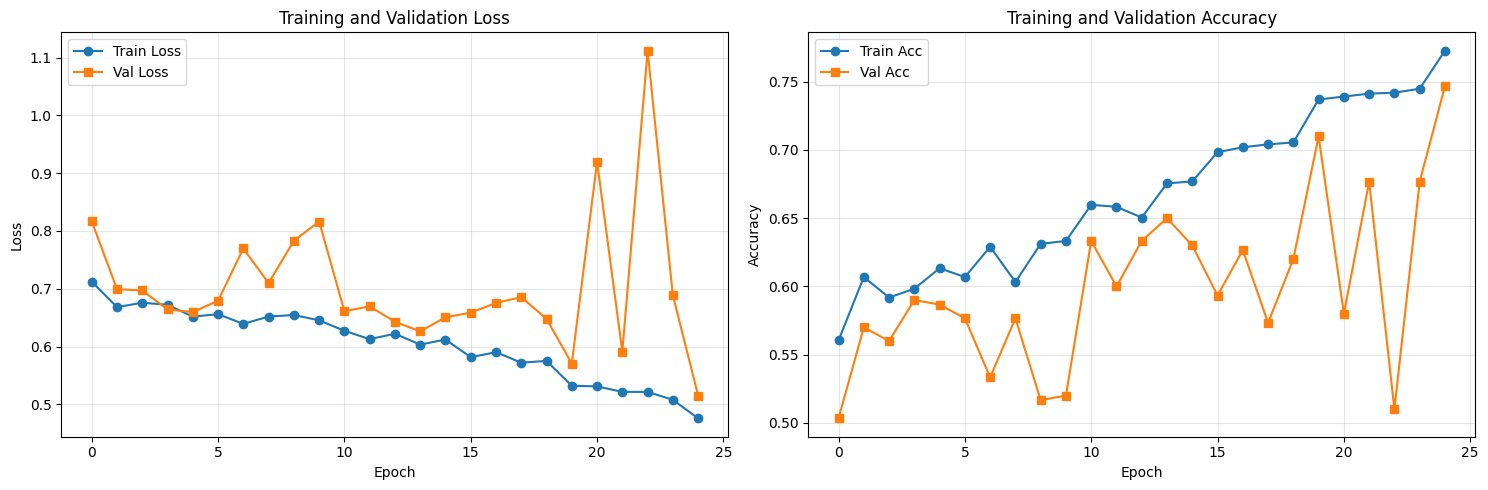

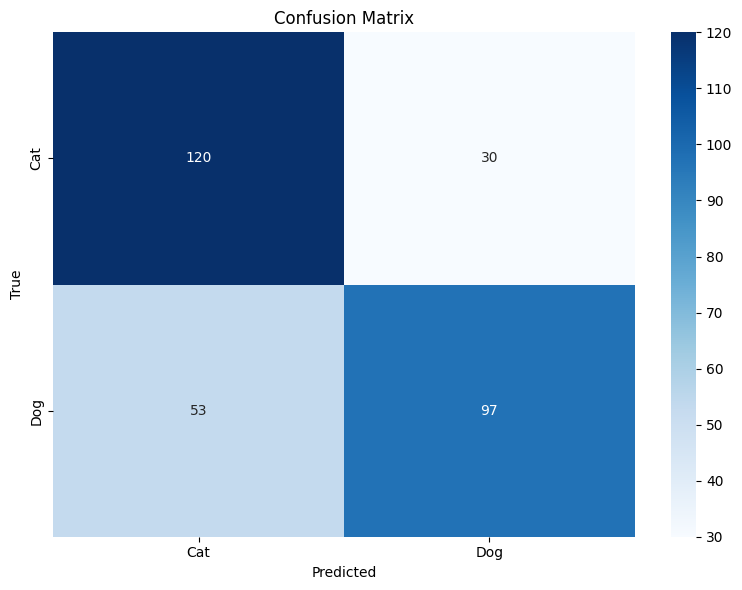


Classification Report:
              precision    recall  f1-score   support

         Cat       0.69      0.80      0.74       150
         Dog       0.76      0.65      0.70       150

    accuracy                           0.72       300
   macro avg       0.73      0.72      0.72       300
weighted avg       0.73      0.72      0.72       300


✅ Финальная модель сохранена: /content/srnet_final_model.pth


In [9]:
# 5. Основной цикл обучения


def main():
    # Настройки
    EPOCHS = 25
    LEARNING_RATE = 1e-3
    WEIGHT_DECAY = 1e-4

    # Устройство
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"  Device: {device}")

    if torch.cuda.is_available():
        print(f"   GPU: {torch.cuda.get_device_name(0)}")
        print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

    # Инициализация модели
    model = SRNet().to(device)
    print(f"\n   Модель загружена на {device}")

    # Функция потерь и оптимизатор
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY
    )

    # Scheduler
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.5,
        patience=3
    )

    # История обучения
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
        'val_auc': []
    }

    # Лучшая модель
    best_val_acc = 0.0
    best_epoch = 0

    print(f"\n{'='*60}")
    print(f"НАЧАЛО ОБУЧЕНИЯ SRNet")
    print(f"{'='*60}")
    print(f"Эпох: {EPOCHS}")
    print(f"Learning rate: {LEARNING_RATE}")
    print(f"Batch size: {BATCH_SIZE}")
    print(f"Image size: {IMAGE_SIZE}x{IMAGE_SIZE}")
    print(f"{'='*60}\n")

    # Цикл обучения
    for epoch in range(EPOCHS):
        print(f"Epoch {epoch+1}/{EPOCHS}")
        print("-" * 60)

        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device
        )

        val_loss, val_acc, val_auc, _, _ = evaluate(
            model, val_loader, criterion, device
        )

        scheduler.step(val_loss)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_auc'].append(val_auc)

        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f} | Val AUC: {val_auc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch + 1
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_acc': val_acc,
            }, '/content/srnet_best_model.pth')
            print(f"   Новая лучшая модель сохранена! (Val Acc: {val_acc:.4f})")

    print(f"\n{'='*60}")
    print(f"ОБУЧЕНИЕ ЗАВЕРШЕНО")
    print(f"{'='*60}")
    print(f"Лучшая точность на валидации: {best_val_acc:.4f} (эпоха {best_epoch})")

    # Загрузка лучшей модели
    checkpoint = torch.load('/content/srnet_best_model.pth')
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"\n   Загружена лучшая модель (эпоха {checkpoint['epoch']+1})")

    # Тестирование
    print(f"\n{'='*60}")
    print(f"ТЕСТИРОВАНИЕ НА ТЕСТОВОМ НАБОРЕ")
    print(f"{'='*60}")

    test_loss, test_acc, test_auc, test_preds, test_labels = evaluate(
        model, test_loader, criterion, device
    )

    print(f"\nTest Loss:  {test_loss:.4f}")
    print(f"Test Acc:   {test_acc:.4f}")
    print(f"Test AUC:   {test_auc:.4f}")

    # Визуализация
    print(f"\n{'='*60}")
    print(f"ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ")
    print(f"{'='*60}")

    plot_training_history(history)
    plot_confusion_matrix(test_labels, test_preds)

    # Сохранение финальной модели
    torch.save(model.state_dict(), '/content/srnet_final_model.pth')
    print(f"\n Финальная модель сохранена: /content/srnet_final_model.pth")

    return model, history


# Запуск обучения
if __name__ == "__main__":
    trained_model, training_history = main()

## Анализ результатов

1. Test Accuracy 72.33% хорошо для простой задачи

2. Test AUC 0.7983 хорошая дискриминация

3. Test Loss 0.5770 ниже валидационного

Небольшой дисбаланс — модель чаще находит кошек (recall 80%), но точнее предсказывает собак (precision 76%).